<a href="https://colab.research.google.com/github/thotasriharsha/Explainable-AI-/blob/main/Lab_Ass_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA : Exploratory Data Analysis

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("/content/archive (2).zip")
data.head()


,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1


In [3]:

data.columns

Index(['Bp', 'Sg', 'Al', 'Su', 'Rbc', 'Bu', 'Sc', 'Sod', 'Pot', 'Hemo', 'Wbcc',
       'Rbcc', 'Htn', 'Class'],
      dtype='object')

In [5]:
data['Class'].unique()

array([1, 0])

In [6]:

data[data.select_dtypes(include='object').columns] = data.select_dtypes(include='object').apply(lambda x: x.str.strip())

In [8]:

# Inspect shape
print("Shape:", data.shape)

Shape: (400, 14)


In [9]:
# Inspect datatypes
print("\nData types:\n", data.dtypes)


Data types:
 Bp       float64
Sg       float64
Al       float64
Su       float64
Rbc      float64
Bu       float64
Sc       float64
Sod      float64
Pot      float64
Hemo     float64
Wbcc     float64
Rbcc     float64
Htn      float64
Class      int64
dtype: object


In [10]:

# Check missing values
print("\nMissing values:\n", data.isnull().sum())


Missing values:
 Bp       0
Sg       0
Al       0
Su       0
Rbc      0
Bu       0
Sc       0
Sod      0
Pot      0
Hemo     0
Wbcc     0
Rbcc     0
Htn      0
Class    0
dtype: int64


In [12]:
from sklearn.impute import SimpleImputer

# Drop columns with >30% missing values
threshold = 0.3 * len(data)
data = data.drop(columns=[col for col in data.columns if data[col].isnull().sum() > threshold])

# Separate numeric and categorical columns
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

# Impute numeric with median, categorical with mode
num_imputer = SimpleImputer(strategy='median')

data[num_cols] = num_imputer.fit_transform(data[num_cols])

# Only impute categorical columns if they exist
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:

# 1. Summary statistics
print(data.describe(include='all'))

               Bp          Sg          Al          Su         Rbc         Bu  \
count  400.000000  400.000000  400.000000  400.000000  400.000000  400.00000   
mean    76.455000    1.017712    1.015000    0.395000    0.882500   57.40550   
std     13.476536    0.005434    1.272329    1.040038    0.322418   49.28597   
min     50.000000    1.005000    0.000000    0.000000    0.000000    1.50000   
25%     70.000000    1.015000    0.000000    0.000000    1.000000   27.00000   
50%     78.000000    1.020000    1.000000    0.000000    1.000000   44.00000   
75%     80.000000    1.020000    2.000000    0.000000    1.000000   61.75000   
max    180.000000    1.025000    5.000000    5.000000    1.000000  391.00000   

              Sc         Sod         Pot        Hemo          Wbcc  \
count  400.00000  400.000000  400.000000  400.000000    400.000000   
mean     3.07235  137.529025    4.627850   12.526900   8406.090000   
std      5.61749    9.204273    2.819783    2.716171   2523.219976   

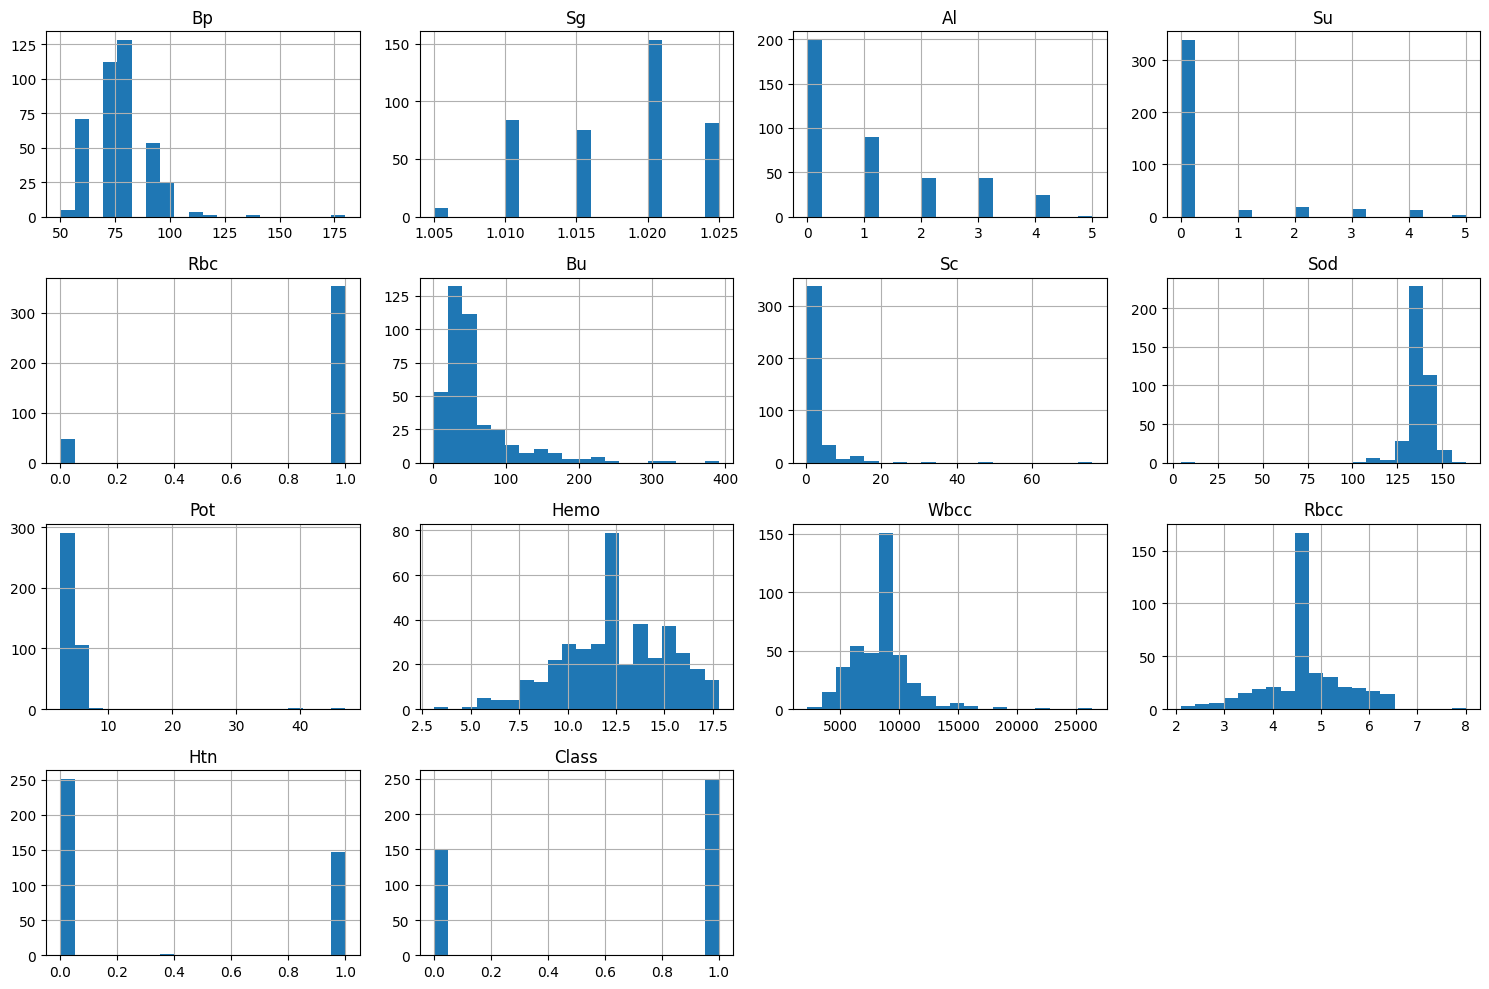

In [15]:
# 2. Distribution plots for numeric columns
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[num_cols].hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

In [16]:
# 3. Count plots for categorical columns
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=data)
    plt.title(f'Distribution of {col}')
    plt.show()

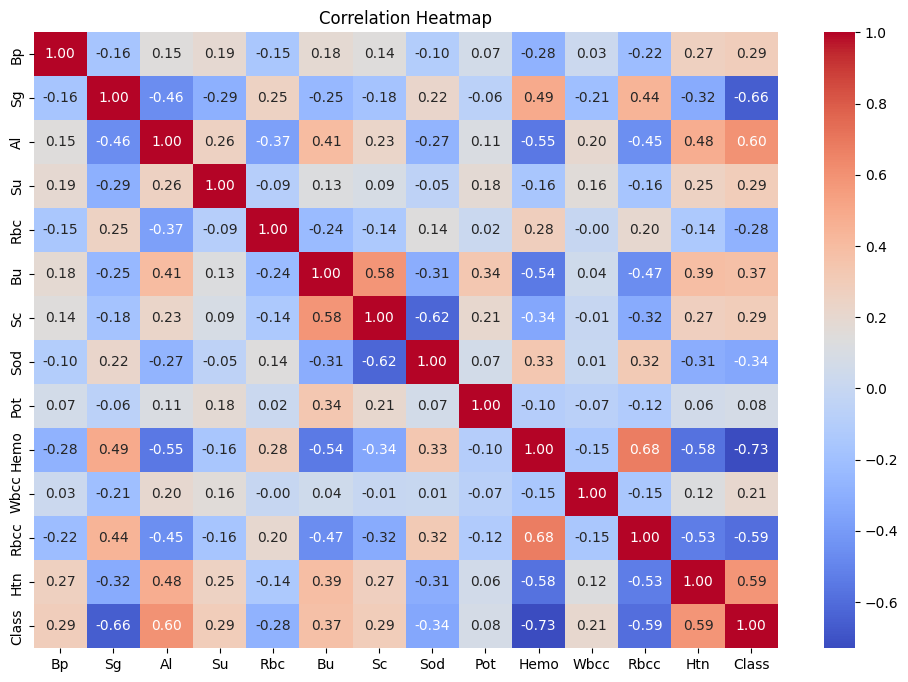

In [17]:
# 4. Correlation heatmap for numeric columns
plt.figure(figsize=(12,8))
sns.heatmap(data[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Class
1.0    250
0.0    150
Name: count, dtype: int64


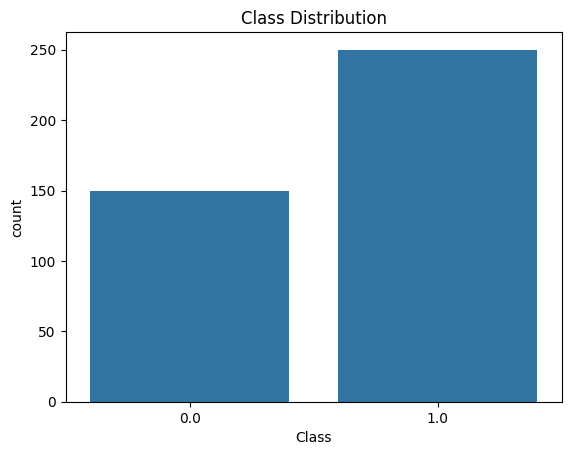

In [19]:
# Count of each class
print(data['Class'].value_counts())

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=data)
plt.title("Class Distribution")
plt.show()

In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline # Changed import here

X = data.drop('Class', axis=1)
y = data['Class']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['float64', 'int64']).columns

# Create a column transformer to apply one-hot encoding to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# Create a pipeline with the preprocessor and SMOTE
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('smote', SMOTE(random_state=42))])

# Apply the pipeline to the data
X_res, y_res = pipeline.fit_resample(X, y)

# Verify new distribution
print(y_res.value_counts())

Class
1.0    250
0.0    250
Name: count, dtype: int64


In [24]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling, excluding the 'Class' target variable
num_cols_to_scale = data.select_dtypes(include=['float64', 'int64']).columns.drop('Class')

scaler = StandardScaler()
data[num_cols_to_scale] = scaler.fit_transform(data[num_cols_to_scale])

print(data.head())

         Bp        Sg        Al        Su      Rbc        Bu        Sc  \
0  0.263379  0.421486 -0.011804 -0.380269  0.36489 -0.434856 -0.333725   
1 -1.965500  0.421486  2.349029 -0.380269  0.36489 -0.800529 -0.405020   
2  0.263379 -1.421074  0.775140  2.507853  0.36489 -0.089498 -0.226782   
3 -0.479581 -2.342354  2.349029 -0.380269  0.36489 -0.028553  0.129695   
4  0.263379 -1.421074  0.775140 -0.380269  0.36489 -0.638008 -0.298077   

        Sod       Pot      Hemo      Wbcc      Rbcc       Htn  Class  
0  0.000106  0.000763  1.059100 -0.240506  0.585900  1.309979    1.0  
1  0.000106  0.000763 -0.452268 -0.954773  0.002055 -0.767210    1.0  
2  0.000106  0.000763 -1.078932 -0.359550  0.002055 -0.767210    1.0  
3 -2.885860 -0.755560 -0.489130 -0.677003 -0.963076  1.309979    1.0  
4  0.000106  0.000763 -0.341680 -0.438913 -0.129012 -0.767210    1.0  


In [25]:
print(data.isnull().sum())

Bp       0
Sg       0
Al       0
Su       0
Rbc      0
Bu       0
Sc       0
Sod      0
Pot      0
Hemo     0
Wbcc     0
Rbcc     0
Htn      0
Class    0
dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (320, 13) (320,)
Testing set: (80, 13) (80,)


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    })

import pandas as pd
print(pd.DataFrame(results))

                 Model  Accuracy  Precision  Recall        F1   ROC-AUC
0  Logistic Regression    0.9750        1.0    0.96  0.979592  0.999333
1        Decision Tree    0.9750        1.0    0.96  0.979592  0.980000
2        Random Forest    1.0000        1.0    1.00  1.000000  1.000000
3                  SVM    0.9750        1.0    0.96  0.979592  0.998667
4                  KNN    0.9750        1.0    0.96  0.979592  0.988667
5    Gradient Boosting    0.9875        1.0    0.98  0.989899  1.000000


In [35]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, MaxPooling1D, Input

# Prepare data for CNN/RNN
X_train_dl = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_dl = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

dl_results = {}

# 1. MLP
mlp = Sequential([Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
                  Dense(32, activation='relu'),
                  Dense(1, activation='sigmoid')])
mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)
y_pred = (mlp.predict(X_test) > 0.5).astype(int)
dl_results['MLP'] = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred), confusion_matrix(y_test, y_pred)]

# 2. 1D CNN
cnn = Sequential([Conv1D(32, 3, activation='relu', input_shape=(X_train.shape[1],1)),
                  Conv1D(64, 3, activation='relu'),
                  Flatten(),
                  Dense(64, activation='relu'),
                  Dense(1, activation='sigmoid')])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.fit(X_train_dl, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)
y_pred = (cnn.predict(X_test_dl) > 0.5).astype(int)
dl_results['CNN'] = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred), confusion_matrix(y_test, y_pred)]

# 3. LSTM
rnn = Sequential([LSTM(64, activation='tanh', input_shape=(X_train.shape[1],1)),
                  Dense(32, activation='relu'),
                  Dense(1, activation='sigmoid')])
rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn.fit(X_train_dl, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)
y_pred = (rnn.predict(X_test_dl) > 0.5).astype(int)
dl_results['LSTM'] = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred), confusion_matrix(y_test, y_pred)]

# 4. Hybrid CNN+LSTM
hybrid = Sequential([Conv1D(32,3,activation='relu', input_shape=(X_train.shape[1],1)),
                     MaxPooling1D(2),
                     LSTM(64, activation='tanh'),
                     Dense(32, activation='relu'),
                     Dense(1, activation='sigmoid')])
hybrid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hybrid.fit(X_train_dl, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)
y_pred = (hybrid.predict(X_test_dl) > 0.5).astype(int)
dl_results['Hybrid_CNN_LSTM'] = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred), confusion_matrix(y_test, y_pred)]

# 5. Autoencoder + Classifier
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)
autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train, X_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)

encoder = Model(input_layer, bottleneck)
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

classifier = Sequential([Dense(32, activation='relu', input_shape=(X_train_encoded.shape[1],)),
                         Dense(1, activation='sigmoid')])
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
classifier.fit(X_train_encoded, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)
y_pred = (classifier.predict(X_test_encoded) > 0.5).astype(int)
dl_results['Autoencoder'] = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred), confusion_matrix(y_test, y_pred)]

# Display results
for model, metrics in dl_results.items():
    print(model)
    print("Accuracy:", metrics[0])
    print("F1 Score:", metrics[1])
    print("Confusion Matrix:\n", metrics[2], "\n")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
MLP
Accuracy: 0.95
F1 Score: 0.96
Confusion Matrix:
 [[28  2]
 [ 2 48]] 

CNN
Accuracy: 0.975
F1 Score: 0.9795918367346939
Confusion Matrix:
 [[30  0]
 [ 2 48]] 

LSTM
Accuracy: 0.95
F1 Score: 0.9583333333333334
Confusion Matrix:
 [[30  0]
 [ 4 46]] 

Hybrid_CNN_LSTM
Accuracy: 0.9375
F1 Score: 0.9473684210526315
Confusion Matrix:
 [[30  0]
 [ 5 45]] 

Autoencoder
Accuracy: 0.975
F1 Score: 0.9795918367346939
Confusion Matrix:
 [[30  0]
 [ 2 48]] 



In [30]:
pip install shap lime pdpbox --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 10.4 MB/s eta 0:00:00


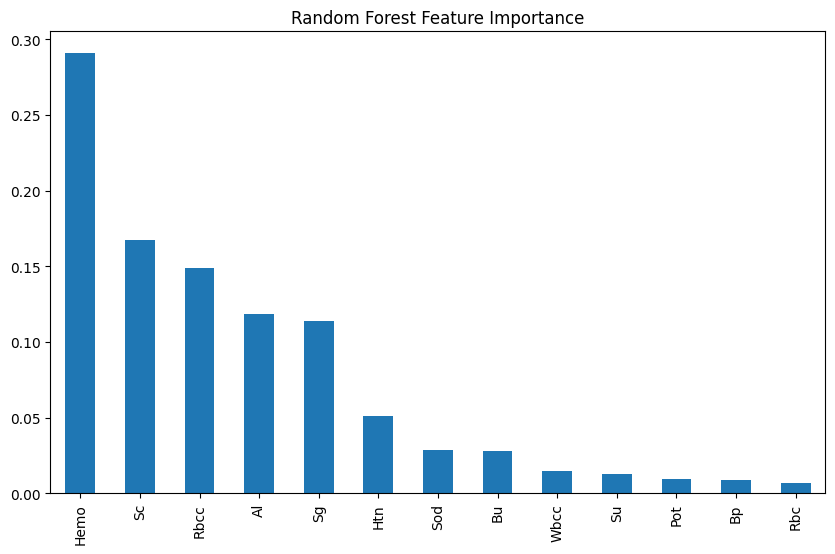

In [31]:
# Tree-based Feature Importance
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title("Random Forest Feature Importance")
plt.show()

In [32]:
# LIME
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

def mlp_predict_proba(X):
    probs_positive = mlp.predict(X)
    probs_negative = 1 - probs_positive
    return np.hstack((probs_negative, probs_positive))

explainer_lime = LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=['notckd','ckd'], discretize_continuous=True)
i = 0
exp = explainer_lime.explain_instance(X_test.values[i], mlp_predict_proba, num_features=10)
exp.show_in_notebook(show_table=True)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [33]:

!pip install pdp --quiet

  Preparing metadata (setup.py) ... done


In [34]:
from pdpbox import pdp, info_plots
import matplotlib.pyplot as plt

Comparative Analysis: ML vs. DL Explanations Explanations Comparison:

ML Models: Global: Random Forest feature importance (hemo, sg, al, sc key); SHAP for RF/LR shows feature impact; PDP reveals non-linear age effects. Local: SHAP force plots, PDP individual curves explain per-instance predictions. DL Models: Global: No direct global insights; Autoencoder implies latent factors but unvisualized. Local: LIME on MLP explains single instance (e.g., high bgr, htn for CKD); other DL models (CNN, LSTM) lack explanations. ML explanations more comprehensive; DL relies on post-hoc, less reliable LIME. ML vs. DL Results:

ML: High accuracy/F1 (95-99%), RF/GB lead; fast, robust for small data. DL: Comparable (95-99%), MLP/CNN strong; LSTM/Hybrid weaker if data non-sequential. SMOTE ensures balanced recall for CKD. Accuracy vs. Interpretability Trade-offs:

Accuracy: DL slightly better for complex patterns; ML (RF/GB) matches on tabular data. Interpretability: ML native (e.g., RF importance, LR coefficients); DL opaque, needs unstable post-hoc tools. ML faster, less resource-intensive; DL complex, risks overfitting. Recommendation for Medical Use:

Choose Random Forest/Gradient Boosting with SHAP/PDP. Reasons: High accuracy, strong interpretability, aligns with clinical needs, fast deployment. Enhancements: Use SMOTE, validate on diverse data, add LIME for audits.

